# Оптимизаторы градиентных алгоритмов: RMSProp, AdaDelta, Adam

In [22]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

## Задача 1: 
Напишите программу поиска точки минимума функции:

$f(x)=−0.5⋅x+0.2⋅x2−0.01⋅x3−0.3⋅sin(4x)$

с помощью градиентного алгоритма с методом импульсов:

$v=γ⋅v+(1−γ)⋅η⋅df(x)dx$

$xn=xn−1−v$

со следующими параметрами и начальными значениями:
```text
η=0.1
x0=−3.5
N=200 - число итераций градиентного алгоритма
γ=0.8
v=0- начальное значение для vv
```
Результат вычисления значения точки минимума xx сохраните в переменной x.

Домашнее задание: попробуйте реализовать тот же градиентный алгоритм но без метода импульсов и сравните результаты.

Минимум найден в x = 0.4606


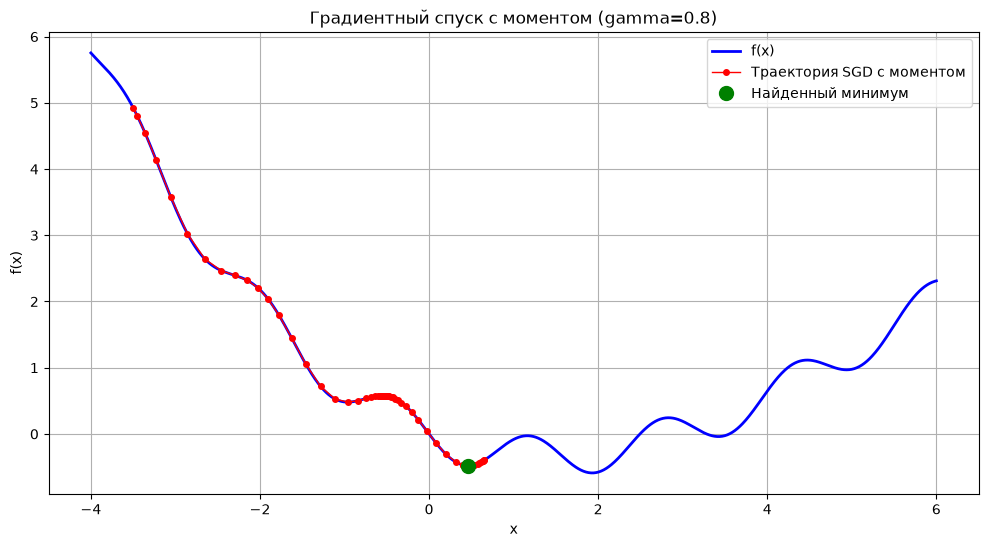

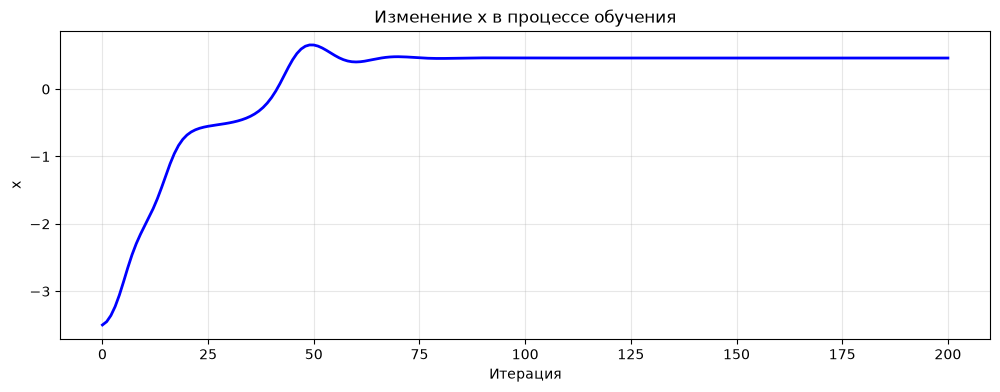

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# находим минимум
def func(x):
    return -0.5 * x + 0.2 * x ** 2 - 0.01 * x ** 3 - 0.3 * np.sin(4*x)

def df(x):
    return -0.5 + 0.4 * x - 0.03 * x ** 2 - 1.2 * np.cos(4 * x)

eta = 0.1 # скорость шарика
# чем больше значение eta, тем больше скорость шарика, то есть больше шаг
x = -3.5
N = 200
gamma = 0.8 # импульс, влияющий на инерцию
# чем меньше значение gamma, тем сильнее импульс (больше колебаний)
v = 0

x_traj = [x]
v_traj = [v]

# метод импульсов (моментов)
for i in range(N):
    v = gamma * v + (1 - gamma) * eta * df(x)
    x = x - v

    x_traj.append(x)
    v_traj.append(v)

# без метода импульсов (моментов)
# for i in range(N):
#     x = x - eta * df(x)

#     x_traj.append(x)

print(f"Минимум найден в x = {x:.4f}")

# строим график
x_plot = np.linspace(-4, 6, 1000)
y_plot = func(x_plot)

plt.figure(figsize=(12, 6))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.plot(x_traj, [func(xi) for xi in x_traj], 'ro-', markersize=4, linewidth=1, label='Траектория SGD с моментом')
plt.plot(x_traj[-1], func(x_traj[-1]), 'go', markersize=10, label='Найденный минимум')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()
plt.title('Градиентный спуск с моментом (gamma=0.8)')
plt.show()

# Дополнительный график - изменение x на каждой итерации
plt.figure(figsize=(12, 4))
plt.plot(range(len(x_traj)), x_traj, 'b-', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('x')
plt.grid(True, alpha=0.3)
plt.title('Изменение x в процессе обучения')
plt.show()

## Задача 2:
Напишите программу поиска точки минимума функции:

$f(x)=0.4⋅x+0.1⋅sin(2x)+0.2⋅cos(3x)$

с помощью градиентного алгоритма с методом импульсов Нестерова:

$v=γ⋅v+(1−γ)⋅η⋅df(x−γ⋅v)dx$

$xn=xn−1−v$

со следующими параметрами и начальными значениями:
```text
    η=1.0
    x0=4.0
    N=500 - число итераций градиентного алгоритма
    γ=0.7
    v=0 - начальное значение для v
```

Результат вычисления значения точки минимума xx сохраните в переменной x.

Домашнее задание: попробуйте реализовать тот же градиентный алгоритм но без метода импульсов Нестерова и сравните результаты.

Минимум найден в x = 0.8117


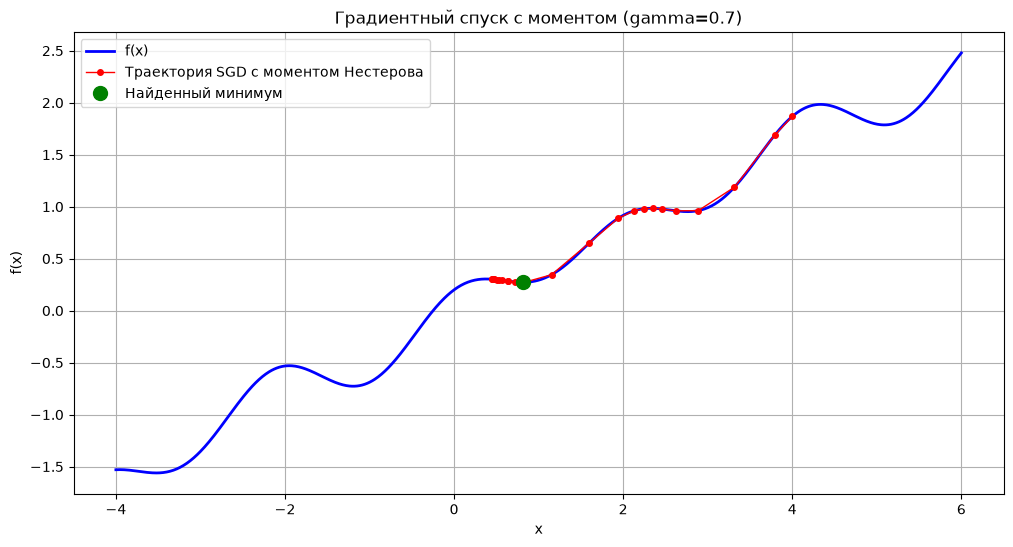

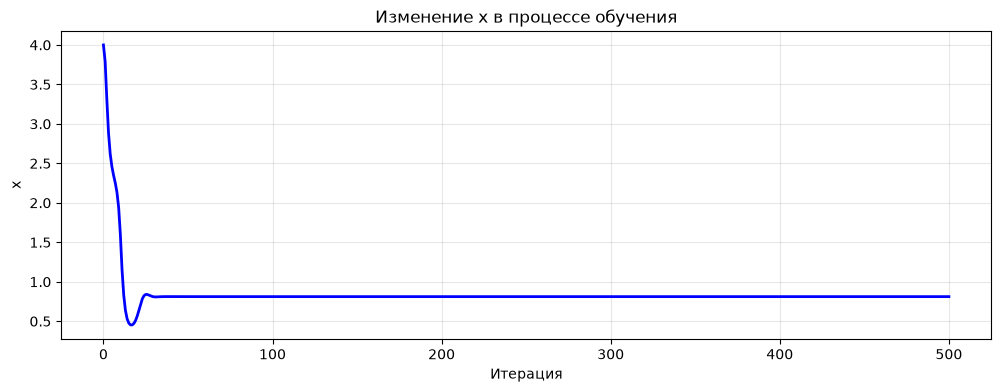

In [34]:
import numpy as np
import matplotlib.pyplot as plt


def func(x):
    return 0.4 * x + 0.1 * np.sin(2*x) + 0.2 * np.cos(3*x)

def df(x):
    return 0.4 + 0.2 * np.cos(2 * x) - 0.6 * np.sin(3 * x)

eta = 1.0
x = 4.0
N = 500
gamma = 0.7
v = 0

x_traj = [x]
v_traj = [v]

# метод импульса Нестерова
for i in range(N):
    v = gamma * v + (1 - gamma) * eta * df(x - gamma * v)
    x = x - v

    x_traj.append(x)
    v_traj.append(v)

# без метода импульса Нестерова
# for i in range(N):
#     x = x - eta * df(x)

#     x_traj.append(x)

print(f"Минимум найден в x = {x:.4f}")

# строим график
x_plot = np.linspace(-4, 6, 1000)
y_plot = func(x_plot)

plt.figure(figsize=(12, 6))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.plot(x_traj, [func(xi) for xi in x_traj], 'ro-', markersize=4, linewidth=1, label='Траектория SGD с моментом Нестерова')
plt.plot(x_traj[-1], func(x_traj[-1]), 'go', markersize=10, label='Найденный минимум')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()
plt.title('Градиентный спуск с моментом (gamma=0.7)')
plt.show()

# Дополнительный график - изменение x на каждой итерации
plt.figure(figsize=(12, 4))
plt.plot(range(len(x_traj)), x_traj, 'b-', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('x')
plt.grid(True, alpha=0.3)
plt.title('Изменение x в процессе обучения')
plt.show()

## Задача 3:
Напишите программу поиска точки минимума функции:

$f(x)=2⋅x+0.1⋅x^3+2⋅cos(3x)$

с помощью градиентного алгоритма с оптимизатором RMSProp:

$G=α⋅G+(1−α)⋅df(x)dx⋅df(x)dx$

$xn=xn−1−η⋅\frac{df(x)/dx}{(\sqrt{G})+ϵ}$

со следующими параметрами и начальными значениями:
```text
    η=0.5
    x0=4.0
    N=200 - число итераций градиентного алгоритма
    α=0.8
    G=0 - начальное значение для GG
    ϵ=0.01
```
Результат вычисления значения точки минимума xx сохраните в переменной x.

Минимум найден в x = 0.6193


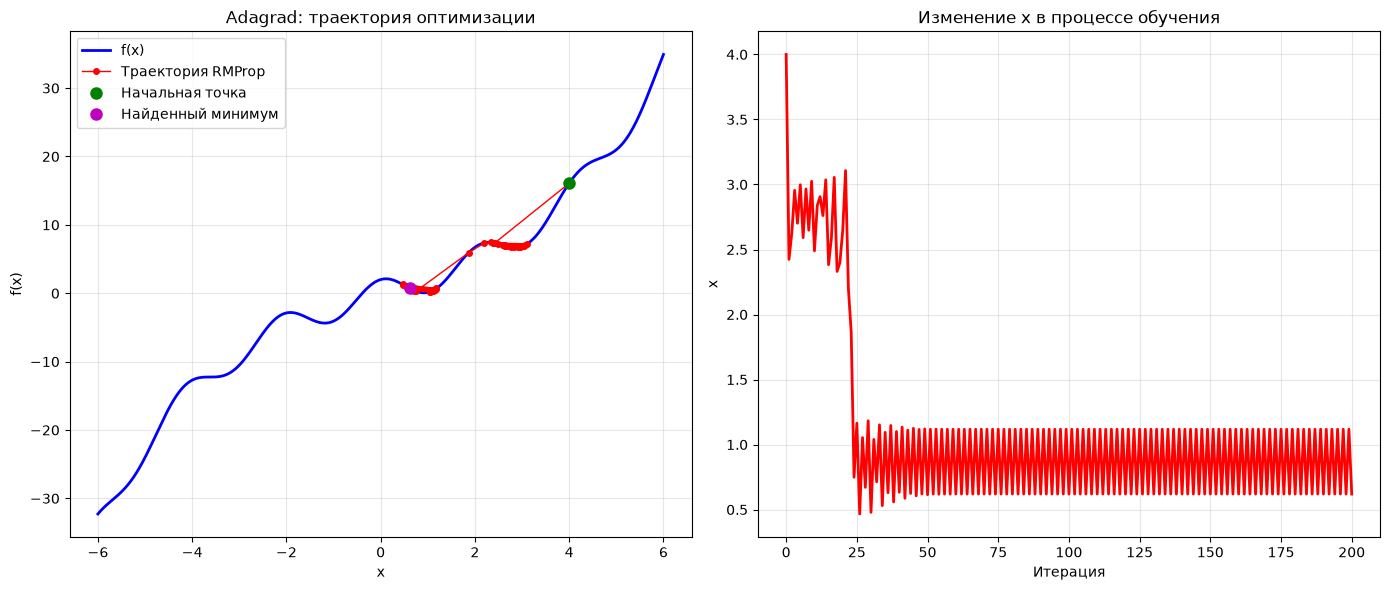

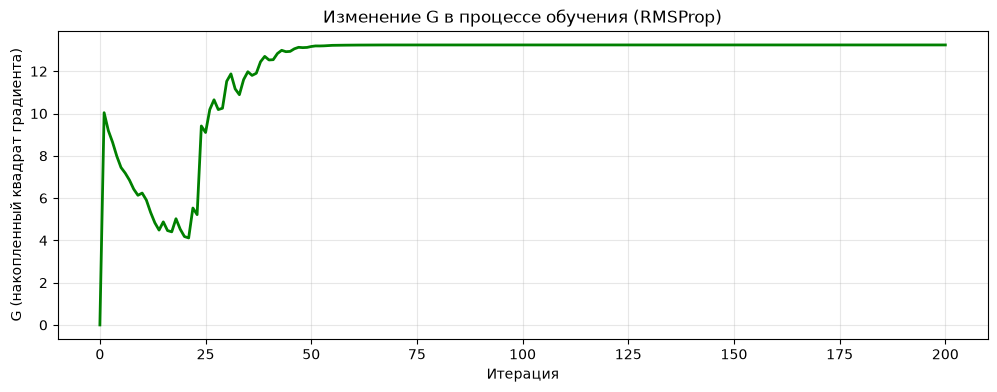

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def func(x):
    return 2 * x + 0.1 * x ** 3 + 2 * np.cos(3*x)

def df(x):
    return 2 + 0.3 * x ** 2 - 6 * np.sin(3 * x)

eta = 0.5 # шаг сходимости
x = 4.0
N = 200
alpha = 0.9 # скорость затухания 
G = 0
epsilon = 0.01

x_traj = [x]
G_traj = [G]

for i in range(N):
    G = alpha * G + (1 - alpha) * df(x) * df(x)
    x = x - eta * df(x) / (np.sqrt(G) + epsilon)
    
    x_traj.append(x)
    G_traj.append(G)

print(f"Минимум найден в x = {x:.4f}")

# График функции и траектории
x_plot = np.linspace(-6, 6, 1000)
y_plot = func(x_plot)

plt.figure(figsize=(14, 6))

# Основной график
plt.subplot(1, 2, 1)
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.plot(x_traj, [func(xi) for xi in x_traj], 'ro-', markersize=4, linewidth=1, label='Траектория RMProp')
plt.plot(x_traj[0], func(x_traj[0]), 'go', markersize=8, label='Начальная точка')
plt.plot(x_traj[-1], func(x_traj[-1]), 'mo', markersize=8, label='Найденный минимум')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Adagrad: траектория оптимизации')

# График изменения x
plt.subplot(1, 2, 2)
plt.plot(range(len(x_traj)), x_traj, 'r-', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('x')
plt.grid(True, alpha=0.3)
plt.title('Изменение x в процессе обучения')

plt.tight_layout()
plt.show()

# Дополнительный график - изменение G (накопленный квадрат градиента)
plt.figure(figsize=(12, 4))
plt.plot(range(len(G_traj)), G_traj, 'g-', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('G (накопленный квадрат градиента)')
plt.grid(True, alpha=0.3)
plt.title('Изменение G в процессе обучения (RMSProp)')
plt.show()

# Задача 4:
Дана функция:

$f(x)=−0.7⋅x−0.2⋅x^2+0.05⋅x^3−0.2⋅cos(3x)+2$

Необходимо выполнить ее аппроксимацию (восстановление) на интервале [-4, 6] моделью вида:

$a(x)=w0+w1⋅x+w2⋅x^2+w3⋅x^3$

Вектор параметров $w=[w0,w1,w2,w3]^T$следует искать с помощью алгоритма стохастического градиентного спуска (SGD) с оптимизатором импульсов Нестерова:

$v=γ⋅v+(1−γ)⋅η⋅\frac{∂Qk(w−γ⋅v)}{∂w}$

$wn=wn−1−v$

где $k$ - случайно выбранный образ из обучающей выборки; $Qk(w)$ - усеченный эмпирический риск:

$Qk(w)=\frac{1}{K}\sum_{i=k}^{k+K−1}(a(x_{i},w)−y_{i})^2=\frac{1}{K}\sum_{i=k}^{k+K−1}(w^T⋅x_{i}−y_{i})^2$

где $x_{i}=[1,x,x2,x3]^T$ - вектор признаков i-го образа; $y_{i}$​ - значение функции $f(x)$ в i-й точке.

Производная усеченного показателя качества может быть записана в следующем векторно-матричном виде:

$\frac{∂Qk(w−γ⋅v)}{∂w}=\frac{2}{K}\sum_{i=k}^{k+K−1}((w−γ⋅v)^T⋅x_{i}−y_{i})⋅x_{i}^T$

То есть, псевдоградиент вычисляется не по одному образу $k$, а по образам в диапазоне [k; k+K) (всего K образов).

Продолжите программу, в которой объявлена функция $f(x)$ с именем func, заданы значения функции по оси абсцисс и ординат, а также начальные значения и параметры для алгоритма SGD с импульсами Нестерова:
```python
import numpy as np

# исходная функция, которую нужно аппроксимировать моделью a(x)
def func(x):
    return -0.7 * x - 0.2 * x ** 2 + 0.05 * x ** 3 - 0.2 * np.cos(3 * x) + 2


# здесь объявляйте необходимые функции


coord_x = np.arange(-4.0, 6.0, 0.1) # значения по оси абсцисс [-4; 6] с шагом 0.1
coord_y = func(coord_x) # значения функции по оси ординат

sz = len(coord_x)	# количество значений функций (точек)
eta = np.array([0.1, 0.01, 0.001, 0.0001]) # шаг обучения для каждого параметра w0, w1, w2, w3
w = np.array([0., 0., 0., 0.]) # начальные значения параметров модели
N = 500 # число итераций алгоритма SGD
lm = 0.02 # значение параметра лямбда для вычисления скользящего экспоненциального среднего
batch_size = 20 # размер мини-батча (величина K = 20)
gamma = 0.8 # коэффициент гамма для вычисления импульсов Нестерова
v = np.zeros(len(w))  # начальное значение [0, 0, 0, 0]

Qe = # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел
```                                

На каждой итерации алгоритма SGD необходимо выбирать начальное значение k командой:
`k = np.random.randint(0, sz-batch_size-1) # sz - размер выборки (массива coord_x)`
и из массива coord_x формировать векторы признаков: $x_{i}=[1,x,x^2,x^3]^T$

для вычисления псевдоградиента $Qk$ по образам от $k$ до $k + batch_size$ (команда 'range(k, k+batch_size)')

Также на каждой итерации нужно пересчитывать значение $Qe$ экспоненциального скользящего среднего по формуле:

$Qe=λ⋅Qk(w)+(1−λ)⋅Qe$

Вычисленные параметры вектора ww следует сохранить в виде списка или кортежа с именем $w$. Также нужно вычислить итоговое значение среднего эмпирического риска для обученной модели по формуле:

$Q(a,X)=\frac{1}{n}\sum_{i=1}^{n}L_{i}(w)$

Вычисленное значение $Q(a,X)$ сохраните в переменной $Q$, а последнее значение $Qe$ - в переменной $Qe$.

In [19]:
import numpy as np


def func(x):
    return -0.7 * x - 0.2 * x ** 2 + 0.05 * x ** 3 - 0.2 * np.cos(3 * x) + 2

def loss(w, x, y):
    return (np.dot(w, x) - y) ** 2

def dQw(w, x, y):
    return 2 * (np.dot(w, x) - y) * x.T


coord_x = np.arange(-4.0, 6.0, 0.1) # значения по оси абсцисс [-4; 6] с шагом 0.1
coord_y = func(coord_x) # значения функции по оси ординат

sz = len(coord_x)	# количество значений функций (точек)
eta = np.array([0.1, 0.01, 0.001, 0.0001]) # шаг обучения для каждого параметра w0, w1, w2, w3
w = np.array([0., 0., 0., 0.]) # начальные значения параметров модели
N = 500 # число итераций алгоритма SGD
lm = 0.02 # значение параметра лямбда для вычисления скользящего экспоненциального среднего
batch_size = 20 # размер мини-батча (величина K = 20)
gamma = 0.8 # коэффициент гамма для вычисления импульсов Нестерова
v = np.zeros(len(w))  # начальное значение [0, 0, 0, 0]

Qe = 0.0
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

for i in range(N):
    k = np.random.randint(0, sz - batch_size - 1)
    
    grad = np.zeros(len(w))
    loss_sum = 0.0
    
    for j in range(k, k + batch_size):
        x = np.array([1, coord_x[j], coord_x[j] ** 2, coord_x[j] ** 3])
        y = coord_y[j]
        
        grad += dQw(w - gamma * v, x, y)
        loss_sum += loss(w - gamma * v, x, y)
    
    grad = grad / batch_size
    Qk = loss_sum / batch_size
    
    v = gamma * v + (1 - gamma) * eta * grad
    w = w - v

    Qe = lm * Qk + (1 - lm) * Qe
 
total_loss = 0.0
for i in range(sz):
    x = np.array([1, coord_x[i], coord_x[i] ** 2, coord_x[i] ** 3])
    y = coord_y[i]
    total_loss += (np.dot(w, x) - y) ** 2

Q = total_loss / sz
print(w)
print(Q)
print(Qe)

[ 2.00087266 -0.69417019 -0.1972715   0.04912324]
0.020238188136794358
0.021599406763296802


## Задание 5:
Дана следующая обучающая выборка для задачи бинарной классификации:
```python
data_x = [(5.3, 2.3), (5.7, 2.5), (4.0, 1.0), (5.6, 2.4), (4.5, 1.5), (5.4, 2.3), (4.8, 1.8), (4.5, 1.5), (5.1, 1.5), (6.1, 2.3), (5.1, 1.9), (4.0, 1.2), (5.2, 2.0), (3.9, 1.4), (4.2, 1.2), (4.7, 1.5), (4.8, 1.8), (3.6, 1.3), (4.6, 1.4), (4.5, 1.7), (3.0, 1.1), (4.3, 1.3), (4.5, 1.3), (5.5, 2.1), (3.5, 1.0), (5.6, 2.2), (4.2, 1.5), (5.8, 1.8), (5.5, 1.8), (5.7, 2.3), (6.4, 2.0), (5.0, 1.7), (6.7, 2.0), (4.0, 1.3), (4.4, 1.4), (4.5, 1.5), (5.6, 2.4), (5.8, 1.6), (4.6, 1.3), (4.1, 1.3), (5.1, 2.3), (5.2, 2.3), (5.6, 1.4), (5.1, 1.8), (4.9, 1.5), (6.7, 2.2), (4.4, 1.3), (3.9, 1.1), (6.3, 1.8), (6.0, 1.8), (4.5, 1.6), (6.6, 2.1), (4.1, 1.3), (4.5, 1.5), (6.1, 2.5), (4.1, 1.0), (4.4, 1.2), (5.4, 2.1), (5.0, 1.5), (5.0, 2.0), (4.9, 1.5), (5.9, 2.1), (4.3, 1.3), (4.0, 1.3), (4.9, 2.0), (4.9, 1.8), (4.0, 1.3), (5.5, 1.8), (3.7, 1.0), (6.9, 2.3), (5.7, 2.1), (5.3, 1.9), (4.4, 1.4), (5.6, 1.8), (3.3, 1.0), (4.8, 1.8), (6.0, 2.5), (5.9, 2.3), (4.9, 1.8), (3.3, 1.0), (3.9, 1.2), (5.6, 2.1), (5.8, 2.2), (3.8, 1.1), (3.5, 1.0), (4.5, 1.5), (5.1, 1.9), (4.7, 1.4), (5.1, 1.6), (5.1, 2.0), (4.8, 1.4), (5.0, 1.9), (5.1, 2.4), (4.6, 1.5), (6.1, 1.9), (4.7, 1.6), (4.7, 1.4), (4.7, 1.2), (4.2, 1.3), (4.2, 1.3)]
data_y = [1, 1, -1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, -1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, -1]
```

Вам необходимо продолжить программу для вычисления вектора параметров:

$w=[w0,w1,w2]^T$

которым описывается разделяющая линия в соответствии с выражением:

$w1⋅x1+w2⋅x2+w0=0$

Вектор параметров $w$ следует искать с помощью алгоритма стохастического градиентного спуска (SGD) с оптимизатором RMSProp:

$G=α⋅G+(1−α)⋅\frac{∂Qk(w)}{∂w}⋅\frac{∂Qk(w)}{∂w}​$

$wn=w_{n−1}−η⋅\frac{∂Qk(w)/∂w}{\sqrt{G}+ϵ}$

где $k$ - случайно выбранный образ из обучающей выборки; $Qk(w)$ - усеченный эмпирический риск:

$Qk(w)=\frac{1}{K}\sum_{i=k}^{k+K−1}L_{i}(w)$

То есть, псевдоградиент вычисляется не по одному образу $k$, а по образам в диапазоне [k; k+K) (всего K образов).

В качестве функции потерь следует выбрать логарифмическую функцию:

$Li(w)=log_{2}(1+e^{−M_{i}})=log_{2}(1+e^{−w^{T}⋅x_{i}⋅y_{i}})$

Ее производная по вектору параметров $w$, равна:

$\frac{∂Li(w)}{∂w}=−\frac{e^{−w^{T}⋅x_{i}⋅y_{i}}⋅x_{i}^{T}⋅y_{i}}{(1+e^{−w^{T}⋅x_{i}⋅y_{i}})⋅ln(2)}​​$

Продолжите программу, в которой сформирована обучающая выборка, заданы функции потерь и ее производной, а также начальные значения и параметры для алгоритма SGD:
```python
import numpy as np
 
# логарифмическая функция потерь
def loss(w, x, y):
    M = np.dot(w, x) * y
    return np.log2(1 + np.exp(-M))

# производная логарифмической функции потерь по вектору w
def df(w, x, y):
    M = np.dot(w, x) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))

data_x = [(5.3, 2.3), (5.7, 2.5), (4.0, 1.0), (5.6, 2.4), (4.5, 1.5), (5.4, 2.3), (4.8, 1.8), (4.5, 1.5), (5.1, 1.5), (6.1, 2.3), (5.1, 1.9), (4.0, 1.2), (5.2, 2.0), (3.9, 1.4), (4.2, 1.2), (4.7, 1.5), (4.8, 1.8), (3.6, 1.3), (4.6, 1.4), (4.5, 1.7), (3.0, 1.1), (4.3, 1.3), (4.5, 1.3), (5.5, 2.1), (3.5, 1.0), (5.6, 2.2), (4.2, 1.5), (5.8, 1.8), (5.5, 1.8), (5.7, 2.3), (6.4, 2.0), (5.0, 1.7), (6.7, 2.0), (4.0, 1.3), (4.4, 1.4), (4.5, 1.5), (5.6, 2.4), (5.8, 1.6), (4.6, 1.3), (4.1, 1.3), (5.1, 2.3), (5.2, 2.3), (5.6, 1.4), (5.1, 1.8), (4.9, 1.5), (6.7, 2.2), (4.4, 1.3), (3.9, 1.1), (6.3, 1.8), (6.0, 1.8), (4.5, 1.6), (6.6, 2.1), (4.1, 1.3), (4.5, 1.5), (6.1, 2.5), (4.1, 1.0), (4.4, 1.2), (5.4, 2.1), (5.0, 1.5), (5.0, 2.0), (4.9, 1.5), (5.9, 2.1), (4.3, 1.3), (4.0, 1.3), (4.9, 2.0), (4.9, 1.8), (4.0, 1.3), (5.5, 1.8), (3.7, 1.0), (6.9, 2.3), (5.7, 2.1), (5.3, 1.9), (4.4, 1.4), (5.6, 1.8), (3.3, 1.0), (4.8, 1.8), (6.0, 2.5), (5.9, 2.3), (4.9, 1.8), (3.3, 1.0), (3.9, 1.2), (5.6, 2.1), (5.8, 2.2), (3.8, 1.1), (3.5, 1.0), (4.5, 1.5), (5.1, 1.9), (4.7, 1.4), (5.1, 1.6), (5.1, 2.0), (4.8, 1.4), (5.0, 1.9), (5.1, 2.4), (4.6, 1.5), (6.1, 1.9), (4.7, 1.6), (4.7, 1.4), (4.7, 1.2), (4.2, 1.3), (4.2, 1.3)]
data_y = [1, 1, -1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, -1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, -1]

x_train = np.array([[1, x[0], x[1]] for x in data_x])
y_train = np.array(data_y)

n_train = len(x_train)  # размер обучающей выборки
w = [0.0, 0.0, 0.0]  # начальные весовые коэффициенты
nt = np.array([0.1, 0.05, 0.05])  # шаг обучения для каждого параметра w0, w1, w2
lm = 0.01  # значение параметра лямбда для вычисления скользящего экспоненциального среднего
N = 200  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)

alpha = 0.7 # параметр для RMSProp
G = np.zeros(len(w))  # параметр для RMSProp
eps = 0.01 # параметр для RMSProp

Qe = # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел
```
На каждой итерации алгоритма SGD необходимо выбирать начальное значение k командой:
```python
k = np.random.randint(0, n_train-batch_size-1) # n_train - размер выборки (массива x_train)
```               
и из массива `x_train` выбирать векторы признаков {xi} для вычисления псевдоградиента по образам от k до k + batch_size (команда `range(k, k+batch_size)`).

Также на каждой итерации нужно пересчитывать значение $Qe$ экспоненциального скользящего среднего по формуле:

$Qe=λ⋅Qk(w)+(1−λ)⋅Qe$

Вычисленные параметры вектора ww следует сохранить в виде списка или кортежа с именем $w$. Также нужно вычислить итоговое значение среднего эмпирического риска для обученной модели по формуле:

$Q(a,X)=\frac{1}{n}⋅\sum_{i=1}^{n}[Mi<0]$

Вычисленное значение $Q(a,X)$ сохраните в переменной $Q$, а последнее значение $Qe$ - в переменной $Qe$.

w = [-4.95162202  0.38310615  1.81559159]
Q = 0.06
Qe = 0.7174181377501041


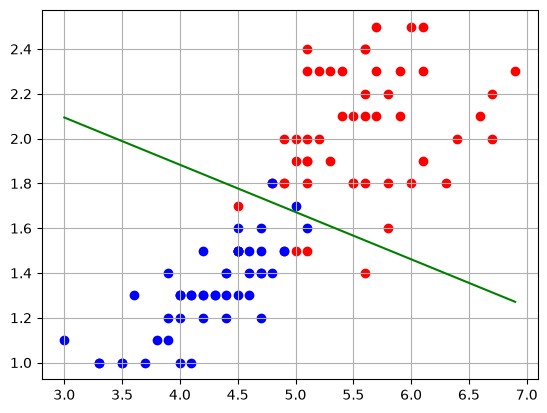

In [24]:
import numpy as np


# логарифмическая функция потерь
def loss(w, x, y):
    M = np.dot(w, x) * y
    return np.log2(1 + np.exp(-M))


# производная логарифмической функции потерь по вектору w
def df(w, x, y):
    M = np.dot(w, x) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))


data_x = [(5.3, 2.3), (5.7, 2.5), (4.0, 1.0), (5.6, 2.4), (4.5, 1.5), (5.4, 2.3), (4.8, 1.8), (4.5, 1.5), (5.1, 1.5), (6.1, 2.3), (5.1, 1.9), (4.0, 1.2), (5.2, 2.0), (3.9, 1.4), (4.2, 1.2), (4.7, 1.5), (4.8, 1.8), (3.6, 1.3), (4.6, 1.4), (4.5, 1.7), (3.0, 1.1), (4.3, 1.3), (4.5, 1.3), (5.5, 2.1), (3.5, 1.0), (5.6, 2.2), (4.2, 1.5), (5.8, 1.8), (5.5, 1.8), (5.7, 2.3), (6.4, 2.0), (5.0, 1.7), (6.7, 2.0), (4.0, 1.3), (4.4, 1.4), (4.5, 1.5), (5.6, 2.4), (5.8, 1.6), (4.6, 1.3), (4.1, 1.3), (5.1, 2.3), (5.2, 2.3), (5.6, 1.4), (5.1, 1.8), (4.9, 1.5), (6.7, 2.2), (4.4, 1.3), (3.9, 1.1), (6.3, 1.8), (6.0, 1.8), (4.5, 1.6), (6.6, 2.1), (4.1, 1.3), (4.5, 1.5), (6.1, 2.5), (4.1, 1.0), (4.4, 1.2), (5.4, 2.1), (5.0, 1.5), (5.0, 2.0), (4.9, 1.5), (5.9, 2.1), (4.3, 1.3), (4.0, 1.3), (4.9, 2.0), (4.9, 1.8), (4.0, 1.3), (5.5, 1.8), (3.7, 1.0), (6.9, 2.3), (5.7, 2.1), (5.3, 1.9), (4.4, 1.4), (5.6, 1.8), (3.3, 1.0), (4.8, 1.8), (6.0, 2.5), (5.9, 2.3), (4.9, 1.8), (3.3, 1.0), (3.9, 1.2), (5.6, 2.1), (5.8, 2.2), (3.8, 1.1), (3.5, 1.0), (4.5, 1.5), (5.1, 1.9), (4.7, 1.4), (5.1, 1.6), (5.1, 2.0), (4.8, 1.4), (5.0, 1.9), (5.1, 2.4), (4.6, 1.5), (6.1, 1.9), (4.7, 1.6), (4.7, 1.4), (4.7, 1.2), (4.2, 1.3), (4.2, 1.3)]
data_y = [1, 1, -1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, -1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, -1]

x_train = np.array([[1, x[0], x[1]] for x in data_x])
y_train = np.array(data_y)

n_train = len(x_train)  # размер обучающей выборки
w = [0.0, 0.0, 0.0]  # начальные весовые коэффициенты
nt = np.array([0.1, 0.05, 0.05])  # шаг обучения для каждого параметра w0, w1, w2
lm = 0.01  # значение параметра лямбда для вычисления скользящего экспоненциального среднего
N = 200  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)

alpha = 0.7 # параметр для RMSProp
G = np.zeros(len(w))  # параметр для RMSProp
eps = 0.01 # параметр для RMSProp

Qe = np.mean([loss(w, x_train[i], y_train[i]) for i in range(n_train)]) # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

for i in range(N):
    k = np.random.randint(0, n_train - batch_size - 1)

    grad = np.zeros(len(w))
    loss_sum = 0.0

    for j in range(k, k + batch_size):
        x = x_train[j]
        y = y_train[j]
        grad += df(w, x, y)
        loss_sum += loss(w, x, y)

    grad = grad / batch_size
    Qk = loss_sum / batch_size

    G = alpha * G + (1 - alpha) * grad * grad
    w = w - nt * grad / (np.sqrt(G) + eps)

    Qe = lm * Qk + (1 - lm) * Qe

M = np.dot(x_train, w) * y_train
Q = np.mean(M < 0)
print(f"w = {w}")
print(f"Q = {Q}")
print(f"Qe = {Qe}")

import matplotlib.pyplot as plt
line_x = [min(x_train[:, 1]), max(x_train[:, 1])]
line_y = [- w[0] / w[2] - w[1] * x / w[2] for x in line_x]
x_0 = x_train[y_train == 1]  # формирование точек для 1-го
x_1 = x_train[y_train == -1]  # и 2-го классов
plt.scatter(x_0[:, 1], x_0[:, 2], color='red')
plt.scatter(x_1[:, 1], x_1[:, 2], color='blue')
plt.plot(line_x, line_y, color='green')
plt.grid(True)
plt.show()